# Aproksymacja liniowa

***Zadanie 1.***

Zdefiniuj funkcję liniową z dowolnymi paramterami $a,b$. Przeprowadź symulację zaszumionego próbkowania jej wartości z przedziału [0,50]. Wykreśl funkcję wraz z jej zaszumionymi próbkami, a następnie dokonaj aproskymacji swojej funkcji za pomocą:
* funkcji liniowej,
* funkcji kwadratowej,
* wielomianu trzeciego stopnia.

Zastosuj metodę/metody minimalizujące najmniejszych kwadratów (normę średniokwadratową np. funkcję *curve_fit* z [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)).

Porównaj otrzymane wyniki z metodami interpolacji poznanymi na poprzednich zajęciach. W tym celu przeprowadź interpolację wygenerowanych danych za pomocą wielomianu interpolacyjnego Lagrange'a oraz za pomocą funkcji sklejanych.

*Wskazówka*: Najpierw wygerneruj tablicę 100 wartości $(x_i, f(x_i))$ dla $x_i \in [0,50]$. Następnie za pomocą np. funkcji *np.random.normal* wygeneruj 100-elementową tablicę szumu losowego i dodaj ją do wygenerowanych **wartości** funkcji (tj. do $f(x_i)$).

Funkcja oryginalna:  f(x) = 2.0x + 5.0
Aproksymacja liniowa:    a=2.0993, b=3.4274
Aproksymacja kwadratowa: [-0.0048645   2.34247862  1.4210045 ]
Aproksymacja 3. stopnia: [-4.14918035e-04  2.62543463e-02  1.72322382e+00  3.93618741e+00]


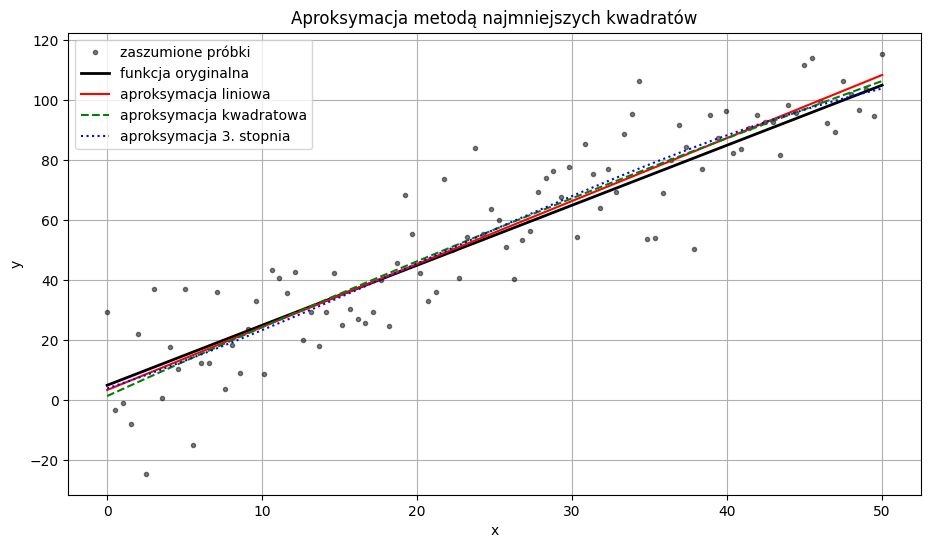

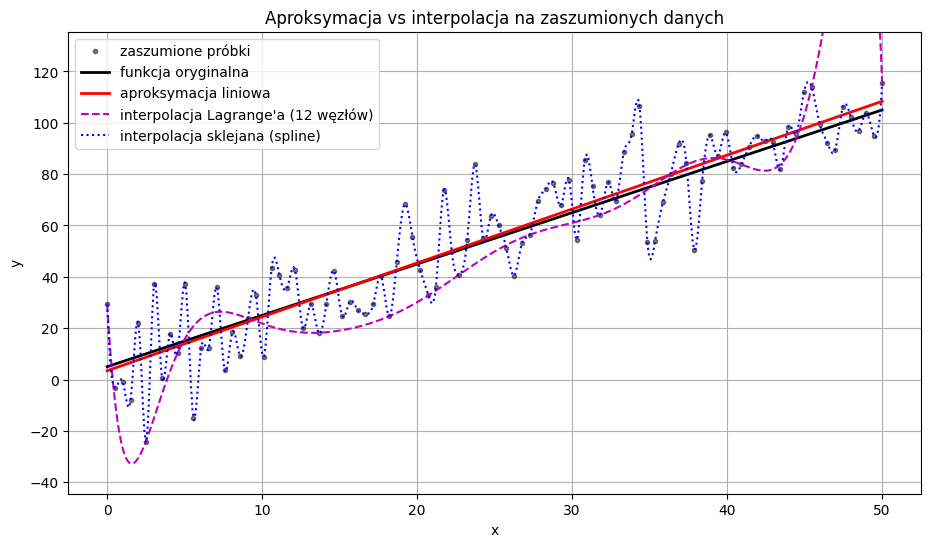

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, interp1d

# --- Funkcja liniowa z dowolnymi parametrami a, b ---
a, b = 2.0, 5.0
f = lambda x: a * x + b

# --- Zaszumione próbkowanie na przedziale [0, 50] ---
np.random.seed(1)
x = np.linspace(0, 50, 100)
y_true = f(x)
noise = np.random.normal(0, 15, 100)   # szum gaussowski
y = y_true + noise

# --- Modele aproksymacji (metoda najmniejszych kwadratów, curve_fit) ---
def model_lin(x, a, b):          return a * x + b
def model_quad(x, a, b, c):      return a * x**2 + b * x + c
def model_cub(x, a, b, c, d):    return a * x**3 + b * x**2 + c * x + d

p_lin, _  = curve_fit(model_lin,  x, y)
p_quad, _ = curve_fit(model_quad, x, y)
p_cub, _  = curve_fit(model_cub,  x, y)

print(f'Funkcja oryginalna:  f(x) = {a}x + {b}')
print(f'Aproksymacja liniowa:    a={p_lin[0]:.4f}, b={p_lin[1]:.4f}')
print(f'Aproksymacja kwadratowa: {p_quad}')
print(f'Aproksymacja 3. stopnia: {p_cub}')

xx = np.linspace(0, 50, 500)

# --- Wykres 1: funkcja, próbki i aproksymacje najmniejszych kwadratów ---
plt.figure(figsize=(11, 6))
plt.plot(x, y, 'k.', alpha=0.5, label='zaszumione próbki')
plt.plot(xx, f(xx), 'k-', lw=2, label='funkcja oryginalna')
plt.plot(xx, model_lin(xx, *p_lin),  'r-',  label='aproksymacja liniowa')
plt.plot(xx, model_quad(xx, *p_quad),'g--', label='aproksymacja kwadratowa')
plt.plot(xx, model_cub(xx, *p_cub),  'b:',  label='aproksymacja 3. stopnia')
plt.xlabel('x'); plt.ylabel('y'); plt.grid()
plt.title('Aproksymacja metodą najmniejszych kwadratów')
plt.legend()
plt.show()

# --- Porównanie z interpolacją (Lagrange + funkcje sklejane) ---
# Interpolacja przechodzi przez KAŻDY (zaszumiony) punkt. Wielomian Lagrange'a
# stopnia 99 jest skrajnie niestabilny, dlatego do porównania bierzemy rzadszą
# podpróbkę punktów; spline budujemy na pełnych danych.
idx = np.linspace(0, 99, 12).astype(int)   # 12 węzłów dla Lagrange'a
L = lagrange(x[idx], y[idx])
S = interp1d(x, y, kind='cubic')

plt.figure(figsize=(11, 6))
plt.plot(x, y, 'k.', alpha=0.5, label='zaszumione próbki')
plt.plot(xx, f(xx), 'k-', lw=2, label='funkcja oryginalna')
plt.plot(xx, model_lin(xx, *p_lin), 'r-', lw=2, label='aproksymacja liniowa')
plt.plot(xx, L(xx), 'm--', label='interpolacja Lagrange\'a (12 węzłów)')
plt.plot(xx, S(xx), 'b:', label='interpolacja sklejana (spline)')
plt.xlabel('x'); plt.ylabel('y'); plt.grid()
plt.title('Aproksymacja vs interpolacja na zaszumionych danych')
plt.legend()
plt.ylim(y.min() - 20, y.max() + 20)
plt.show()


**Wnioski (Zadanie 1):**

- **Aproksymacja** (najmniejsze kwadraty) wygładza dane — nie przechodzi przez poszczególne (zaszumione) punkty, lecz minimalizuje sumę kwadratów odchyleń. Aproksymacja liniowa dobrze odtwarza oryginalne parametry $a, b$; modele wyższych stopni dopasowują się nieco lepiej do szumu, ale współczynniki przy wyższych potęgach są bliskie zeru (dane są w istocie liniowe).
- **Interpolacja** wymusza przejście przez każdy punkt, więc wiernie odwzorowuje szum — jest to niepożądane przy danych pomiarowych. Wielomian Lagrange'a wysokiego stopnia dodatkowo silnie oscyluje (efekt Rungego), a spline kopiuje zaszumiony przebieg.
- **Wniosek:** do danych obarczonych szumem właściwą metodą jest **aproksymacja**, a nie interpolacja — interpolacja ma sens tylko dla danych dokładnych.


***Zadanie 2.***


Wykorzystaj metody aproksymacji do rozwiązania zadania z kierowcą z poprzednich ćwiczeń.


Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

Aproksymacja kwadratowa: s(t) = -5.8500 t^2 + 48.3500 t + 0.0500

Kierowca minął fotoradar w chwili t = 2.2672 s
Prędkość w tym momencie: v = 21.8232 m/s = 78.56 km/h


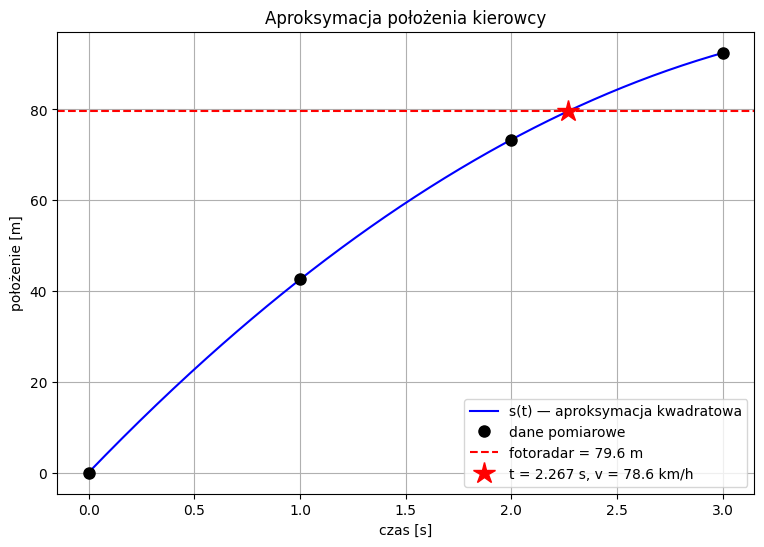


Wynik jest zgodny z metodą interpolacyjną z Lab 5 (≈78 km/h) —
aproksymacja kwadratowa dobrze opisuje ruch opóźniony (hamowanie).


In [2]:
# Dane pomiarowe: czas [s] i położenie [m]
t = np.array([0.0, 1.0, 2.0, 3.0])
s = np.array([0.0, 42.7, 73.2, 92.5])
s_radar = 79.6

# Tym razem zamiast interpolacji stosujemy APROKSYMACJĘ.
# Dane opisują hamowanie (ruch opóźniony) -> najmniejsze kwadraty wielomianem 2. st.
# s(t) = c2*t^2 + c1*t + c0
coef = np.polyfit(t, s, 2)
S = np.poly1d(coef)
print(f'Aproksymacja kwadratowa: s(t) = {coef[0]:.4f} t^2 + {coef[1]:.4f} t + {coef[2]:.4f}')

# Szukamy chwili, w której s(t) = 79.6 (metoda z laboratorium 3 — tu pierwiastki wielomianu)
r = (S - s_radar).roots
r = r[np.isreal(r)].real
t_radar = r[(r >= 0) & (r <= 3)][0]

# Prędkość = pochodna położenia
v_radar = np.polyder(S)(t_radar)
print(f'\nKierowca minął fotoradar w chwili t = {t_radar:.4f} s')
print(f'Prędkość w tym momencie: v = {v_radar:.4f} m/s = {v_radar * 3.6:.2f} km/h')

# Wykres
xx = np.linspace(0, 3, 300)
plt.figure(figsize=(9, 6))
plt.plot(xx, S(xx), 'b-', label='s(t) — aproksymacja kwadratowa')
plt.plot(t, s, 'ko', markersize=8, label='dane pomiarowe')
plt.axhline(s_radar, color='r', ls='--', label=f'fotoradar = {s_radar} m')
plt.plot(t_radar, s_radar, 'r*', markersize=16, label=f't = {t_radar:.3f} s, v = {v_radar*3.6:.1f} km/h')
plt.xlabel('czas [s]'); plt.ylabel('położenie [m]')
plt.title('Aproksymacja położenia kierowcy'); plt.legend(); plt.grid()
plt.show()

print('\nWynik jest zgodny z metodą interpolacyjną z Lab 5 (≈78 km/h) —')
print('aproksymacja kwadratowa dobrze opisuje ruch opóźniony (hamowanie).')


***Zadanie 3.***


Spróbuj przeprowadzić regresję liniową (aproksymację funkcją liniową) na rzeczywistych danych (np. z repozytorium [UCI](https://archive.ics.uci.edu/ml/datasets.php?format=&task=reg&att=&area=&numAtt=&numIns=&type=&sort=nameUp&view=table)). Wykorzystaj stworzony model do predykcji. Dla ułatwienia możesz zastosować funkcję z biblioteki [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

Model: y = 998.58 * BMI + 152.00
Współczynnik R^2 (test): 0.2334
RMSE (test):             63.73

Predykcja modelu:
  BMI(znormalizowane) = -0.090  ->  postęp choroby ≈ 61.9
  BMI(znormalizowane) = +0.000  ->  postęp choroby ≈ 152.0
  BMI(znormalizowane) = +0.171  ->  postęp choroby ≈ 322.3


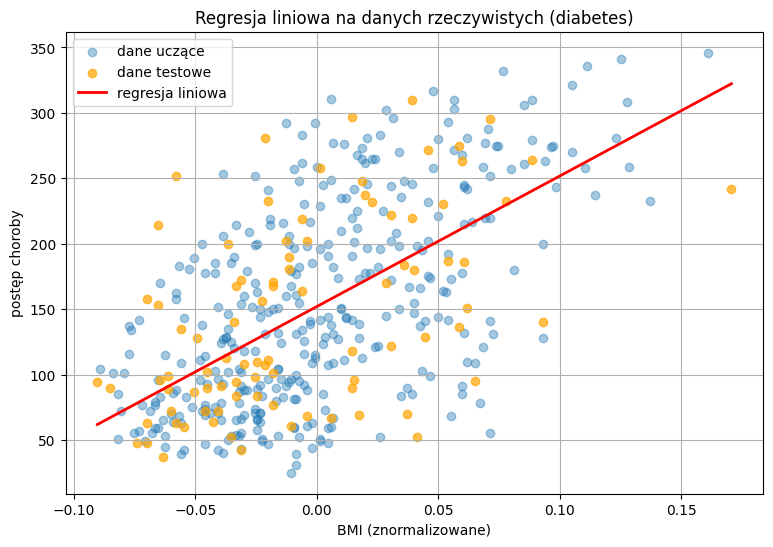


Wniosek: BMI jest dodatnio skorelowane z postępem choroby, ale pojedyncza
cecha tłumaczy tylko część zmienności (R^2 ≈ 0.23). Pełny model regresji
wieloczynnikowej (wszystkie cechy) dawałby znacznie lepsze dopasowanie.


In [3]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Rzeczywiste dane: zbiór "diabetes" (UCI / sklearn).
# Regresja liniowa: zależność postępu choroby od wskaźnika BMI pacjenta.
data = load_diabetes()
X = data.data[:, [2]]      # cecha BMI (indeks 2)
Y = data.target            # miara postępu choroby

# Podział na zbiór uczący i testowy
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Model regresji liniowej (aproksymacja funkcją liniową)
model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

print(f'Model: y = {model.coef_[0]:.2f} * BMI + {model.intercept_:.2f}')
print(f'Współczynnik R^2 (test): {r2_score(Y_test, Y_pred):.4f}')
print(f'RMSE (test):             {np.sqrt(mean_squared_error(Y_test, Y_pred)):.2f}')

# Predykcja dla przykładowych wartości
przyklad = np.array([[X.min()], [0.0], [X.max()]])
print('\nPredykcja modelu:')
for xv, pv in zip(przyklad.ravel(), model.predict(przyklad)):
    print(f'  BMI(znormalizowane) = {xv:+.3f}  ->  postęp choroby ≈ {pv:.1f}')

# Wykres
plt.figure(figsize=(9, 6))
plt.scatter(X_train, Y_train, alpha=0.4, label='dane uczące')
plt.scatter(X_test, Y_test, color='orange', alpha=0.7, label='dane testowe')
xline = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(xline, model.predict(xline), 'r-', lw=2, label='regresja liniowa')
plt.xlabel('BMI (znormalizowane)'); plt.ylabel('postęp choroby')
plt.title('Regresja liniowa na danych rzeczywistych (diabetes)')
plt.legend(); plt.grid()
plt.show()

print('\nWniosek: BMI jest dodatnio skorelowane z postępem choroby, ale pojedyncza')
print('cecha tłumaczy tylko część zmienności (R^2 ≈ 0.23). Pełny model regresji')
print('wieloczynnikowej (wszystkie cechy) dawałby znacznie lepsze dopasowanie.')
